# Proyecto Final: Sistema de Recomendación E-commerce
## EDA Primario (Exploratorio)

**Equipo:** MetricEdge

**Autor:** Simón Bedoya

**Dataset:** E-commerce Sales & Customer Analytics (150k), Kaggle



### Objetivo de este notebook

Este es un diagnóstico liviano de calidad de datos. El objetivo es entender la estructura de las cuatro tablas, detectar problemas de calidad (nulos, duplicados, inconsistencias) y dejar argumentada cada decisión de limpieza. El resultado de este notebook es una lista de reglas confirmadas para el ETL.


## 1. Carga de datos crudos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (9, 4.5)

customer = pd.read_csv('../data/raw/customer_master.csv')
product = pd.read_csv('../data/raw/product_catalog.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')
sales = pd.read_csv('../data/raw/ecommerce_sales_customer_analytics_150k.csv')

sales['order_date'] = pd.to_datetime(sales['order_date'])

print('customer_master  :', customer.shape)
print('product_catalog  :', product.shape)
print('order_items      :', order_items.shape)
print('sales            :', sales.shape)

customer_master  : (25000, 11)
product_catalog  : (1175, 9)
order_items      : (397569, 12)
sales            : (138116, 46)


## 2. Entendimiento del esquema



In [2]:
display(customer.head(3))
display(product.head(3))

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53


,product_id,product_name,product_category,product_subcategory,brand,supplier,unit_price,product_cost,product_rating
0,PROD-000001,Apple Sharable bifurcated algorithm Smartphones,Electronics,Smartphones,Apple,Alibaba,686.90,474.06,4.3
1,PROD-000002,Google User-centric even-keeled encryption Sma...,Electronics,Smartphones,Google,Euro Logistics,978.26,519.66,2.9
2,PROD-000003,LG Face-to-face client-driven support Smartphones,Electronics,Smartphones,LG,Asian Manufacturing,275.51,185.48,3.9


In [3]:
# Vista completa de sales, sin recortar columnas, para tener el panorama global de la tabla
display(sales.head(3))

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,customer_type,customer_city,customer_state,customer_country,region,customer_postal_code,payment_method,payment_status,currency,shipping_method,warehouse,delivery_days,estimated_delivery_days,delivery_status,return_status,return_reason,customer_rating,review_sentiment,customer_review,marketing_channel,campaign_name,coupon_code,loyalty_points_earned,loyalty_points_redeemed,quantity,gross_sales,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,Loyal,Lake Williamberg,Texas,USA,South,86040,Digital Wallet,Paid,USD,Standard,WH-003,3.0,3.0,On Time,NaN,NaN,3.5,Positive,Satisfied with the purchase.,Direct,Default_Campaign,NaN,94,44,5,1350.19,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,Loyal,Kristyport,Baden-Württemberg,Germany,South,62538,Debit Card,Pending,EUR,Economy,WH-005,10.0,10.0,On Time,NaN,NaN,3.6,Positive,Good value for money.,Direct,Default_Campaign,NaN,201,171,8,3144.64,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,Loyal,Singletonhaven,New York,USA,East,19993,Cash on Delivery,Paid,USD,Express,WH-015,3.0,3.0,On Time,NaN,NaN,4.3,Positive,Good product. Works as expected.,YouTube,NaN,NaN,46,16,5,522.81,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6


In [4]:
display(order_items.head(3))

,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
0,ORD-301242,PROD-000738,2,244.40,0.339607,166.00,488.80,22.60,6.48,351.88,173.28,172.12
1,ORD-301242,PROD-000181,3,287.13,0.362076,311.89,861.39,38.47,5.55,593.52,415.05,172.92
2,ORD-773460,PROD-000973,4,754.80,0.468300,1413.89,3019.20,305.01,9.00,1919.32,1976.16,-65.84


**customer_master**: un registro por cliente. Dimensión cliente.

**product_catalog**: un registro por producto. Dimensión producto.

**sales**: un registro por orden completa (order_id único), con el estado, el cliente, el canal y variables agregadas de la orden. Se muestra completa (sus 46 columnas) para tener una vista global real de todo lo que contiene, no un recorte.

**order_items**: un registro por línea de producto dentro de una orden (order_id + product_id), con 12 columnas que describen precio, descuento, impuesto, envío, costo y utilidad de cada línea. Es la única tabla que sabe qué productos específicos componen cada orden, de ahí que cualquier análisis de comportamiento de compra deba construirse desde aquí, no desde sales.

## 3. Integridad referencial

Antes de cualquier cruce entre tablas, se confirma que las llaves calcen sin huérfanos.

In [5]:
print('order_id en order_items sin match en sales   :', len(set(order_items.order_id) - set(sales.order_id)))
print('order_id en sales sin match en order_items   :', len(set(sales.order_id) - set(order_items.order_id)))
print('product_id en order_items sin match en catalog:', len(set(order_items.product_id) - set(product.product_id)))
print('customer_id en sales sin match en customer_master:', len(set(sales.customer_id) - set(customer.customer_id)))

order_id en order_items sin match en sales   : 0
order_id en sales sin match en order_items   : 0
product_id en order_items sin match en catalog: 0
customer_id en sales sin match en customer_master: 0


**Resultado:** cero llaves huérfanas en las cuatro combinaciones. Las tablas se pueden cruzar sin riesgo de pérdida silenciosa de filas.

## 4. Valores nulos

No todos los nulos significan lo mismo. Hay que distinguir entre nulo aleatorio (dato faltante real) y nulo estructural (ausencia legítima de una condición). Se revisan las cuatro tablas, no solo la que tiene nulos, para dejar constancia explícita de que las otras tres están limpias en este frente, en vez de solo afirmarlo sin evidencia.

In [6]:
print('=== Nulos en customer_master ===')
print(customer.isnull().sum().sum(), 'valores nulos en total')

=== Nulos en customer_master ===
0 valores nulos en total


In [7]:
print('=== Nulos en product_catalog ===')
print(product.isnull().sum().sum(), 'valores nulos en total')

=== Nulos en product_catalog ===
0 valores nulos en total


In [8]:
print('=== Nulos en order_items ===')
print(order_items.isnull().sum().sum(), 'valores nulos en total')

=== Nulos en order_items ===
0 valores nulos en total


Las tres tablas anteriores no tienen ningún valor nulo. El problema de nulos está concentrado únicamente en sales.

In [9]:
nulos_sales = (sales.isnull().mean()*100).round(2).sort_values(ascending=False)
print(nulos_sales[nulos_sales > 0])

return_reason              93.15
return_status              93.15
coupon_code                80.01
campaign_name              60.26
estimated_delivery_days    17.78
delivery_days              17.78
customer_rating            17.78
review_sentiment           17.78
customer_review            17.78
dtype: float64


In [21]:
print('return_reason es nulo solo cuando return_status NO es Returned ')
print(sales.groupby('return_status', dropna=False)['return_reason'].apply(lambda x: x.isnull().mean()*100))

return_reason es nulo solo cuando return_status NO es Returned 
return_status
Returned      0.0
NaN         100.0
Name: return_reason, dtype: float64


Cuando return_status es Returned, return_reason nunca es nulo. El nulo en ambas columnas es estructural, representa "esta orden no fue devuelta". Lo mismo aplica para coupon_code (nulo cuando no se usó cupón) y campaign_name (nulo cuando la venta no vino de una campaña).

Los nulos de customer_review, customer_rating, delivery_days, estimated_delivery_days y review_sentiment (17.78% cada uno) coinciden con órdenes que no llegaron a Completed, así que no requieren tratamiento aparte: quedan naturalmente excluidos cuando se filtre por estado de orden (regla 2).

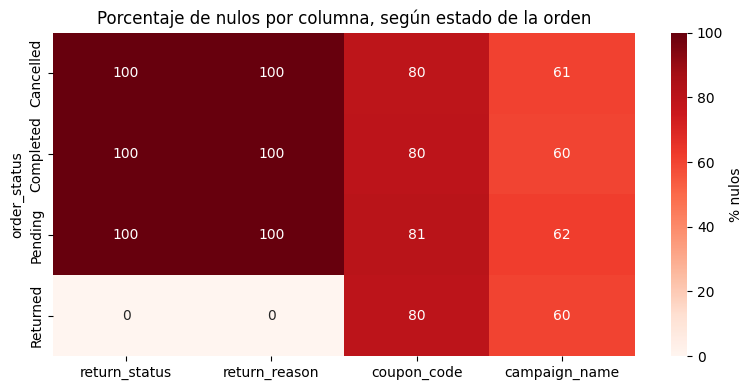

In [22]:
# Mapa de calor: porcentaje de nulos por columna, agrupado por order_status,
# para demostrar visualmente que la ausencia de datos no es aleatoria sino
# que sigue un patron segun el estado de la orden.
columnas_revisar = ['return_status', 'return_reason', 'coupon_code', 'campaign_name']
pct_nulos_por_status = sales.groupby('order_status')[columnas_revisar].apply(lambda x: x.isnull().mean()*100)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pct_nulos_por_status, annot=True, fmt='.0f', cmap='Reds', cbar_kws={'label': '% nulos'}, ax=ax)
ax.set_title('Porcentaje de nulos por columna, según estado de la orden')
plt.tight_layout()
plt.show()

El mapa de calor muestra dos patrones distintos, ambos estructurales y ninguno aleatorio. return_status y return_reason están 100% vacíos en toda orden que no sea Returned, confirmando que dependen directamente del estado de la orden. coupon_code y campaign_name, en cambio, tienen un porcentaje de nulos similar sin importar el estado de la orden, lo que confirma que su ausencia depende de si se usó cupón o campaña, no del estado de la compra.

**Decisión: ninguno de estos datos faltantes se completó con un promedio o con un valor inventado. Se recategorizan explícitamente** ("Sin devolución", "Sin cupón", "Sin campaña"), para no perder esa información.

## 5. Duplicados

Se revisan dos tipos de duplicado distintos: que cada tabla que debería tener una fila única por entidad (cliente, producto, orden) efectivamente la tenga, y que el detalle de órdenes no repita la misma combinación de orden y producto.

### 5.1 Duplicados de llave primaria en las tablas de una sola entidad

Antes de revisar el caso ya conocido de order_items, se confirma que customer_master, product_catalog y sales no tengan más de una fila para el mismo identificador, porque si la tuvieran, cualquier cruce posterior se multiplicaría de forma incorrecta.

In [23]:
print('customer_id duplicados en customer_master:', customer.customer_id.duplicated().sum())
print('product_id duplicados en product_catalog  :', product.product_id.duplicated().sum())
print('order_id duplicados en sales               :', sales.order_id.duplicated().sum())

customer_id duplicados en customer_master: 0
product_id duplicados en product_catalog  : 0
order_id duplicados en sales               : 0


**Resultado:** cero duplicados de llave primaria en las tres tablas. Cada cliente, cada producto y cada orden aparece exactamente una vez donde se espera que así sea.

### 5.2 Duplicados en order_items

In [24]:
dup_par = order_items.duplicated(subset=['order_id','product_id']).sum()
print('Pares (order_id, product_id) duplicados:', dup_par)

ejemplo = order_items[order_items.duplicated(subset=['order_id','product_id'], keep=False)] \
    .sort_values(['order_id','product_id']).head(4)
display(ejemplo)

Pares (order_id, product_id) duplicados: 87


,order_id,product_id,quantity,unit_price,discount_percentage,discount_amount,gross_sales,tax_amount,shipping_cost,net_sales,product_cost,profit
292639,ORD-116240,PROD-001079,4,42.15,0.043355,7.31,168.60,11.29,3.67,176.25,52.04,120.54
364770,ORD-116240,PROD-001079,1,42.15,0.123642,5.21,42.15,2.59,23.72,63.25,13.01,26.52
101373,ORD-124215,PROD-000044,4,863.97,0.144428,499.13,3455.88,206.97,21.24,3184.96,2016.44,1147.28
138789,ORD-124215,PROD-000044,1,863.97,0.096381,83.27,863.97,148.33,4.76,933.79,504.11,424.92


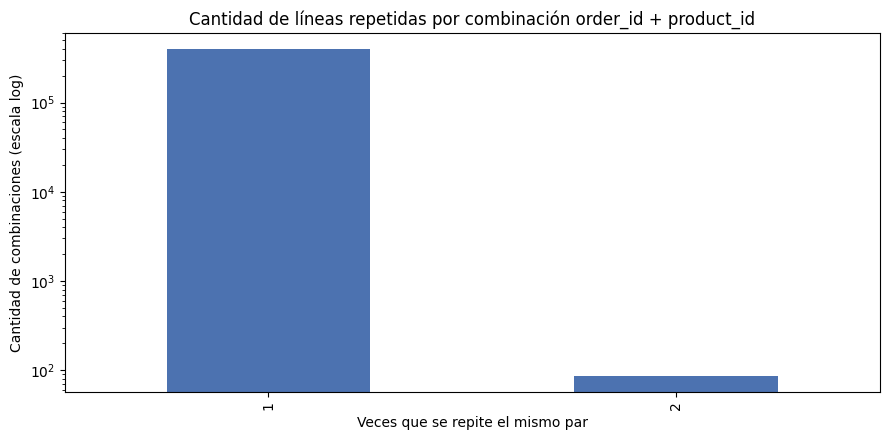

In [25]:
# Histograma de cuantas veces se repite cada par order_id + product_id,
# para visualizar que la inmensa mayoria de las lineas no tiene duplicado,
# y que el problema es acotado (87 pares) frente a las 397.569 filas totales.
conteo_repeticion = order_items.groupby(['order_id','product_id']).size()

fig, ax = plt.subplots()
conteo_repeticion.value_counts().plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('Cantidad de líneas repetidas por combinación order_id + product_id')
ax.set_xlabel('Veces que se repite el mismo par')
ax.set_ylabel('Cantidad de combinaciones (escala log)')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

87 pares order_id + product_id aparecen más de una vez (siempre dos veces, nunca más), con cantidades y montos distintos en cada aparición, consistente con el mismo producto agregado al carrito en más de un momento dentro de la misma orden.

**Decisión: agregar (sumar o recalcular según corresponda) estas líneas por order_id + product_id**, conservando las 12 columnas originales de order_items, antes de cualquier análisis de comportamiento.

## 6. order_status: qué interacciones reflejan preferencia real

In [15]:
conteo_status = sales.order_status.value_counts()
print(conteo_status)
print((conteo_status / conteo_status.sum() * 100).round(2))

order_status
Completed    113559
Returned       9462
Cancelled      8398
Pending        6697
Name: count, dtype: int64
order_status
Completed    82.22
Returned      6.85
Cancelled     6.08
Pending       4.85
Name: count, dtype: float64


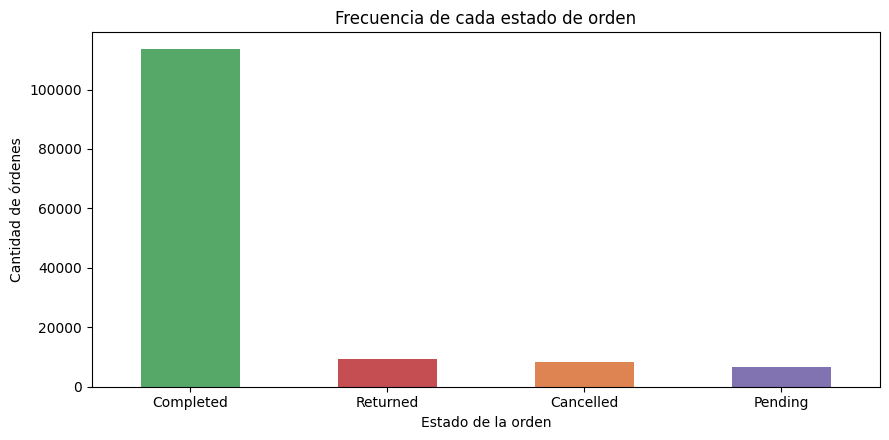

In [26]:
fig, ax = plt.subplots()
conteo_status.plot(kind='bar', ax=ax, color=['#55A868', '#C44E52', '#DD8452', '#8172B2'])
ax.set_title('Frecuencia de cada estado de orden')
ax.set_xlabel('Estado de la orden')
ax.set_ylabel('Cantidad de órdenes')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Completed (82.22%) y Returned (6.85%) reflejan una compra que sí ocurrió, el cliente sí eligió el producto. Cancelled (6.08%) nunca se concretó. Pending (4.85%) es indeterminado.

**Decisión: solo Completed y Returned cuentan como interacción real** para cualquier análisis de comportamiento de compra.

## 7. Consistencia de customer_order_count

El dataset trae una columna ya calculada con el total histórico de órdenes por cliente. Antes de usarla, se verifica cómo fue construida.

In [28]:
print('¿El valor varia entre las distintas filas de un mismo cliente?')
variabilidad = sales.groupby('customer_id')['customer_order_count'].nunique()
print('Clientes con valor variable entre sus filas:', (variabilidad > 1).sum(), 'de', variabilidad.shape[0])

¿El valor varia entre las distintas filas de un mismo cliente?
Clientes con valor variable entre sus filas: 0 de 24911


In [29]:
conteo_real = sales.groupby('customer_id').size().rename('conteo_real')
comparacion = sales[['customer_id','customer_order_count']].drop_duplicates('customer_id').merge(conteo_real, on='customer_id')
comparacion['coincide'] = comparacion['customer_order_count'] == comparacion['conteo_real']
print('Porcentaje de clientes donde coincide exactamente:', round(comparacion['coincide'].mean()*100, 2), '%')

Porcentaje de clientes donde coincide exactamente: 62.17 %


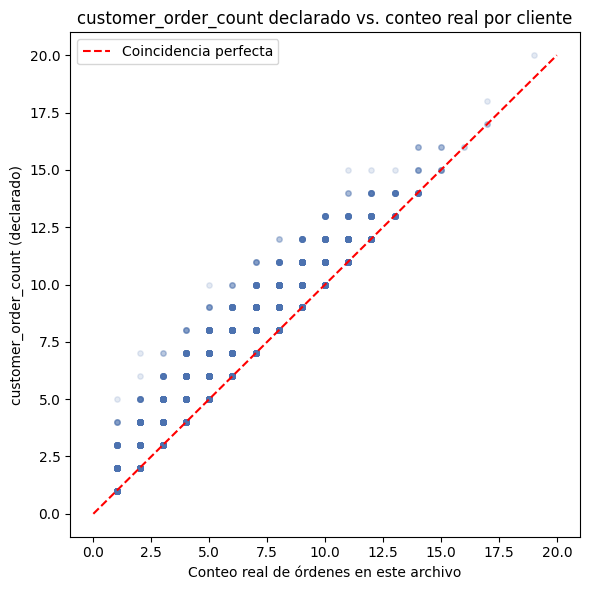

In [30]:
# Dispersion entre el valor declarado y el conteo real, para visualizar
# que tan lejos se desvia cada cliente de la diagonal (donde coincidirian
# exacto). Los puntos fuera de la diagonal son los casos inconsistentes.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comparacion['conteo_real'], comparacion['customer_order_count'], alpha=0.15, s=15, color='#4C72B0')
lim_max = max(comparacion['conteo_real'].max(), comparacion['customer_order_count'].max())
ax.plot([0, lim_max], [0, lim_max], color='red', linestyle='--', label='Coincidencia perfecta')
ax.set_xlabel('Conteo real de órdenes en este archivo')
ax.set_ylabel('customer_order_count (declarado)')
ax.set_title('customer_order_count declarado vs. conteo real por cliente')
ax.legend()
plt.tight_layout()
plt.show()

Dos problemas confirmados: el valor es fijo por cliente sin importar la fecha de cada orden (no es un conteo acumulado), y no coincide con el conteo real de órdenes presentes en este archivo en más de un tercio de los casos, visible en el gráfico como los puntos que caen por encima de la línea de coincidencia perfecta, lo que sugiere que este archivo es un extracto de una población más grande.

**Decisión: no usar customer_order_count ni is_repeat_customer tal como vienen. Recalcular un conteo acumulado propio, ordenado por fecha, usando solo las órdenes presentes en este archivo**, para evitar fuga de información hacia el futuro del cliente y la inconsistencia con los datos disponibles.

## 8. Clientes sin ninguna orden

In [20]:
clientes_sin_orden = set(customer.customer_id) - set(sales.customer_id)
print('Clientes sin ninguna orden:', len(clientes_sin_orden))
print('Porcentaje sobre el total: {:.2f}%'.format(len(clientes_sin_orden)/customer.shape[0]*100))

Clientes sin ninguna orden: 89
Porcentaje sobre el total: 0.36%


89 clientes (0.36%) existen en customer_master pero nunca hicieron ninguna orden, ni siquiera cancelada.

**Decisión: se marcan explícitamente (no se eliminan de customer_master), y se excluyen de cualquier análisis de comportamiento de compra**, porque no hay ninguna señal que aprender de ellos.

## 9. Reglas de limpieza confirmadas para el ETL

Ninguna regla se agrega al ETL si no está primero aquí, justificada con evidencia de las secciones anteriores.

1. **Deduplicar order_items**: agrupar por order_id + product_id, conservando las 12 columnas originales con el criterio de agregación correcto para cada una (sección 5.2).
2. **Filtrar order_status**: solo Completed y Returned cuentan como interacción real (sección 6).
3. **Recategorizar return_status y return_reason** nulos como "Sin devolución" (sección 4).
4. **Recategorizar coupon_code y campaign_name** nulos como "Sin cupón" y "Sin campaña" (sección 4).
5. **No imputar los nulos de posventa** (customer_review, customer_rating, delivery_days, estimated_delivery_days, review_sentiment): quedan excluidos naturalmente al aplicar la regla 2 (sección 4).
6. **Marcar y excluir del análisis de comportamiento a los 89 clientes sin ninguna orden**, conservándolos en customer_master para análisis demográfico general (sección 8).
7. **Recalcular customer_order_count de forma acumulada por fecha**, descartando la columna original y is_repeat_customer (sección 7).
8. **Cualquier split de entrenamiento y prueba debe respetar la secuencia de order_date**, nunca un split aleatorio, por la misma razón de fuga de información de la regla 7.